<a href="https://colab.research.google.com/github/Ramon-udc/GCED-AA2/blob/main/es/p1/Practica1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Práctica 1

En este ejercicio se va a crear un sistema de aprendizaje supervisado sobre el dataset [ISOLET](https://archive.ics.uci.edu/dataset/54/isolet). Ten en cuenta que este es un problema de clasificación multiclase. Las etiquetas son números enteros que indican la clase. Tu modelo debe predecir un vector que represente una distribución de probabilidad a lo largo de las distintas clases. La función de pérdida que debes utilizar es [nn.CrossEntropyLoss](https://docs.pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html). Fíjate en que esta función espera que la salida de tu red no esté normalizada con una función softmax (lee la documentación y haz pruebas para aprender a utilizarla correctamente).

## Carga del dataset

Esta celda se encargará de bajar el dataset a vuestro ordenador. Tened en cuenta que puede haber fallos, ya que el repositorio de UCI desde donde se descarga tiene muchas peticiones simultáneas.

In [13]:
import os
import numpy as np
from scipy.io import loadmat
import torch
import random
from sklearn.model_selection import KFold

# Fijamos la semilla para poder reproducir los resultados
seed = 1234
os.environ['PYTHONHASHSEED'] = str(seed)
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

def download_dataset(directory):
    if not os.path.isdir(directory):
        os.makedirs(directory)

    filename = 'Isolet.mat'
    url = 'https://jundongl.github.io/scikit-feature/files/datasets/Isolet.mat'
    filepath = os.path.join(directory, filename)

    if not os.path.isfile(filepath):
        torch.hub.download_url_to_file(url, filepath)


def load_dataset(directory=None):
    directory = directory or './isolet/'
    download_dataset(directory=directory)
    dataset = load_data(directory + 'Isolet.mat')
    return dataset


def load_data(source):
    dataset = loadmat(source)
    return dataset['X'].astype(np.float32), dataset['Y'].astype(int)


In [14]:
from sklearn.model_selection import train_test_split
import torch.utils.data as data

# Cargamos el dataset
X, y = load_dataset()
y = y - 1
n_classes = np.unique(y).size

# Usa estas particiones exactamente
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)

## Preprocesado

Preprocesa los datos como necesites, con el objetivo de facilitar el entrenamiento de la red. Recuerda que, si vas a utilizar valores estadísticos de los datos, éstos sólo pueden ser obtenidos de los datos de la partición de train. Es decir, **no se puede aplicar la función fit (o fit_transform) sobre los datos de validación o test**.

In [15]:
from sklearn.preprocessing import StandardScaler

# TODO - Haz el preprocesado que necesites
# Ajustamos el escalador únicamente con el conjunto de entrenamiento
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## Trabajo a realizar

```
 NOTA: Para todos los entrenamientos se utilizarán los siguientes parámetros:
 - Adam como optimizador
 - Tasa de aprendizaje de 0.001
 - Tamaño de batch de 100
 - Duración de 100 iteraciones (epochs).
```

### 1. Entrenamiento simple
Entrena un modelo de red neuronal totalmente conectada. El número de capas ocultas será de 2, con 50 neuronas por capa, una regularización l2 de 0.01, y ReLU como función de activación para las capas ocultas. Utiliza [KFold](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.KFold.html) para el particionamiento, probando con distintos valores de k (3, 5 y 10).

Debes ser capaz de responder a las siguientes preguntas:
1. ¿Cuál es la precisión del modelo?
1. ¿Qué conclusiones sacas respecto a la variación de los resultados al cambiar k?

In [16]:
# TODO - Entrenamiento simple
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

class SimpleMLP(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(SimpleMLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 50),
            nn.ReLU(),
            nn.Linear(50, 50),
            nn.ReLU(),
            nn.Linear(50, output_dim)
        )

    def forward(self, x):
        return self.network(x)

def train_and_evaluate(k_values, X_data, y_data):
    input_dim = X_data.shape[1]
    output_dim = n_classes

    for k in k_values:
        kf = KFold(n_splits=k, shuffle=True, random_state=seed)
        fold_accuracies = []

        for fold, (train_idx, val_idx) in enumerate(kf.split(X_data)):
            X_tr, y_tr = X_data[train_idx], y_data[train_idx]
            X_val, y_val = X_data[val_idx], y_data[val_idx]

            # Escalado correcto por Fold
            fold_scaler = StandardScaler()
            X_tr_scaled = fold_scaler.fit_transform(X_tr)
            X_val_scaled = fold_scaler.transform(X_val)

            train_dataset = TensorDataset(torch.tensor(X_tr_scaled), torch.tensor(y_tr.flatten()).long())
            train_loader = DataLoader(train_dataset, batch_size=100, shuffle=True)

            model = SimpleMLP(input_dim, output_dim)
            criterion = nn.CrossEntropyLoss()
            # L2 regularizacion con weight_decay = 0.01
            optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=0.01)

            model.train()
            for epoch in range(100):
                for batch_x, batch_y in train_loader:
                    optimizer.zero_grad()
                    outputs = model(batch_x)
                    loss = criterion(outputs, batch_y)
                    loss.backward()
                    optimizer.step()

            model.eval()
            with torch.no_grad():
                val_outputs = model(torch.tensor(X_val_scaled))
                preds = torch.argmax(val_outputs, dim=1)
                acc = (preds == torch.tensor(y_val.flatten())).float().mean().item()
                fold_accuracies.append(acc)

        print(f"Resultados para K={k}: Precisión media = {np.mean(fold_accuracies):.4f} +/- {np.std(fold_accuracies):.4f}")

train_and_evaluate([3, 5, 10], X_train, y_train)


Resultados para K=3: Precisión media = 0.9407 +/- 0.0030
Resultados para K=5: Precisión media = 0.9487 +/- 0.0148
Resultados para K=10: Precisión media = 0.9455 +/- 0.0100


### 2. Búsqueda de mejores hiperparámetros
Para un k-fold con k=3, queremos buscar un modelo que se adecúe de la mejor manera posible al problema. Para ello, probaremos distintas configuraciones. En concreto, se entrenarán modelos con todas las variaciones posibles de los parámetros siguientes:
1. 1, 5 o 10 capas ocultas
1. 10, 50 o 100 número de neuronas de las capas ocultas (todas las capas usarán el mismo valor)
1. 4 valores distintos de regularización por norma l2 (0.0001, 0.001, 0.01 o 0.1).
1. 2 funciones de activación distintas para la capa oculta (ReLU o Tanh).

Asegúrate de que:
 - Se han realizado todas las permutaciones posibles
 - No hay repeticiones innecesarias de código
 - No se ha utilizado el conjunto de validación para entrenar el modelo (ni como criterio de parada)
 - Al final de los entrenamientos, se muestra la precisión (accuracy) del mejor y del peor modelo, así como los parámetros que se han utilizado para crear dichos modelos. También se mostrará la precisión del modelo obtenida con los datos usados en entrenamiento.
 - Para los mejores y peores modelos, investiga si están sobreentrenando o si les falta capacidad.
 - Identificas qué hiperparámetros afectan más y cuáles menos al entrenamiento.

In [17]:
activations = ['relu', 'tanh']
regularizations = [1e-4, 1e-3, 1e-2, 1e-1]
hidden_layer_elements_list = [10, 50, 100]
n_hidden_layers_list = [1, 5, 10]

# Registra los resultados en estos diccionarios respetando el formato dado
resultados_train = {}
resultados_validacion = {}

# Inicializar diccionarios vacíos en la estructura correcta
for act in activations:
    resultados_train[act] = {}
    resultados_validacion[act] = {}
    for reg in regularizations:
        resultados_train[act][reg] = {}
        resultados_validacion[act][reg] = {}
        for hid_n in hidden_layer_elements_list:
            resultados_train[act][reg][hid_n] = {}
            resultados_validacion[act][reg][hid_n] = {}

# TODO - Búsqueda de hiperparámetros
import itertools

class ConfigurableMLP(nn.Module):
    def __init__(self, input_dim, output_dim, n_layers, n_neurons, activation_name):
        super(ConfigurableMLP, self).__init__()
        layers = []
        in_features = input_dim
        for _ in range(n_layers):
            layers.append(nn.Linear(in_features, n_neurons))
            if activation_name == 'relu':
                layers.append(nn.ReLU())
            else:
                layers.append(nn.Tanh())
            in_features = n_neurons
        layers.append(nn.Linear(in_features, output_dim))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

# Combinaciones
input_dim = X_train.shape[1]
output_dim = n_classes
kf = KFold(n_splits=3, shuffle=True, random_state=seed)

best_val = -1.0
worst_val = 2.0
best_config = None
worst_config = None

permutations = list(itertools.product(activations, regularizations, hidden_layer_elements_list, n_hidden_layers_list))

for act, reg, hid_n, n_hid in permutations:
    train_accs = []
    val_accs = []

    for train_idx, val_idx in kf.split(X_train):
        X_tr, y_tr = X_train[train_idx], y_train[train_idx]
        X_val, y_val = X_train[val_idx], y_train[val_idx]

        fold_scaler = StandardScaler()
        X_tr_scaled = fold_scaler.fit_transform(X_tr)
        X_val_scaled = fold_scaler.transform(X_val)

        train_dataset = TensorDataset(torch.tensor(X_tr_scaled), torch.tensor(y_tr.flatten()).long())
        train_loader = DataLoader(train_dataset, batch_size=100, shuffle=True)

        model = ConfigurableMLP(input_dim, output_dim, n_hid, hid_n, act)
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=reg)

        model.train()
        for epoch in range(100):
            for batch_x, batch_y in train_loader:
                optimizer.zero_grad()
                outputs = model(batch_x)
                loss = criterion(outputs, batch_y)
                loss.backward()
                optimizer.step()

        model.eval()
        with torch.no_grad():
            t_outputs = model(torch.tensor(X_tr_scaled))
            t_preds = torch.argmax(t_outputs, dim=1)
            t_acc = (t_preds == torch.tensor(y_tr.flatten())).float().mean().item()
            train_accs.append(t_acc)

            v_outputs = model(torch.tensor(X_val_scaled))
            v_preds = torch.argmax(v_outputs, dim=1)
            v_acc = (v_preds == torch.tensor(y_val.flatten())).float().mean().item()
            val_accs.append(v_acc)

    train_score = np.mean(train_accs)
    val_score = np.mean(val_accs)

    resultados_train[act][reg][hid_n][n_hid] = train_score
    resultados_validacion[act][reg][hid_n][n_hid] = val_score

    if val_score > best_val:
        best_val = val_score
        best_config = (act, reg, hid_n, n_hid)
    if val_score < worst_val:
        worst_val = val_score
        worst_config = (act, reg, hid_n, n_hid)

print(f"Mejor modelo (Val): {best_config} con precisión: {best_val:.4f}. Precisión en Train: {resultados_train[best_config[0]][best_config[1]][best_config[2]][best_config[3]]:.4f}")
print(f"Peor modelo (Val): {worst_config} con precisión: {worst_val:.4f}. Precisión en Train: {resultados_train[worst_config[0]][worst_config[1]][worst_config[2]][worst_config[3]]:.4f}")


Mejor modelo (Val): ('tanh', 0.0001, 100, 1) con precisión: 0.9519. Precisión en Train: 1.0000
Peor modelo (Val): ('relu', 0.01, 10, 10) con precisión: 0.0272. Precisión en Train: 0.0457


### 3. Visualiza los resultados

Usa el código de la siguiente celda para visualizar la precisión mediante el uso de mapas de calor. Usa las siguientes combinaciones:
1. Número de capas ocultas vs Número de neuronas por capa
1. Número de capas ocultas vs Regularización
1. Número de neuronas por capa vs Regularización

```Vigila el no repetir código innecesariamente. No se deben re-entrenar los modelos, ya que las estadísticas deben haber sido guardadas en el formato apropiado en el punto anterior.```


Analiza los resultados. ¿Qué problemáticas entiendes que se están produciendo?

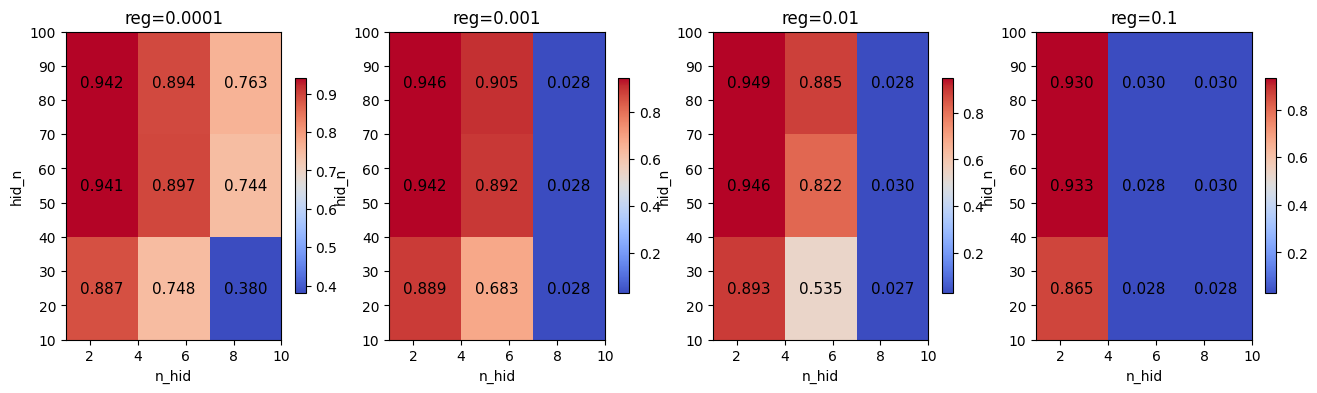

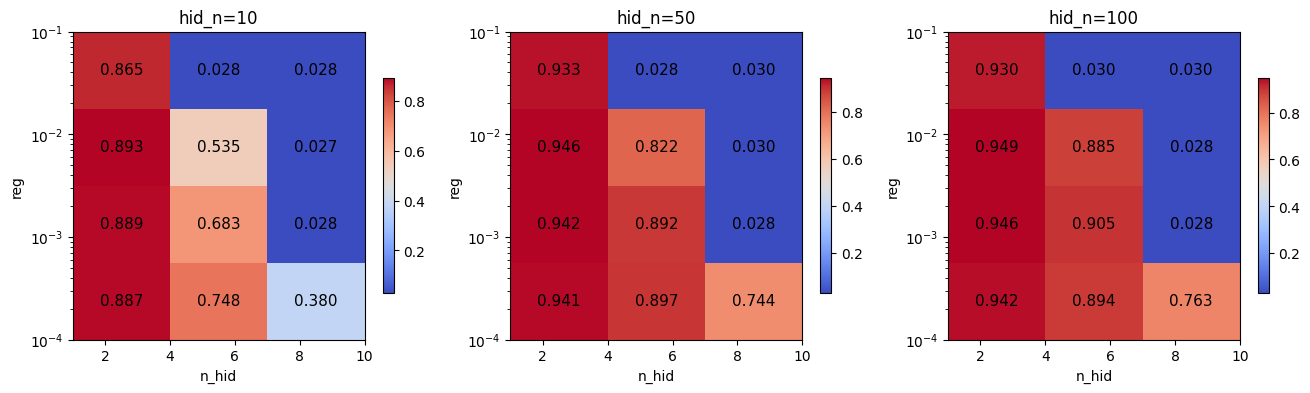

In [18]:
# Se facilita el código de generación del mapa de calor a partir de los resultados registrados

import matplotlib.pyplot as plt
from matplotlib import cm
import numpy as np

def plot_heatmap_with_values(results, grids, xaxis, yaxis, naxis, activation, fmt="{:.3f}", log_y=False):
    X = np.array(grids[xaxis])
    Y = np.array(grids[yaxis])


    fig, ax_t = plt.subplots(1,len(grids[naxis]), figsize=(16,4))
    for n, nv in enumerate(grids[naxis]):
        ax = ax_t[n]
        # Build Z grid
        Z = []
        comb = {}
        comb['act'] = activation
        comb[naxis] = nv
        for yval in grids[yaxis]:
            comb[yaxis] = yval
            Z_row = []
            for xval in grids[xaxis]:
                comb[xaxis] = xval
                Z_row.append(results[comb['act']][comb['reg']][comb['hid_n']][comb['n_hid']])
            Z.append(Z_row)
        Z = np.array(Z)

        # Compute cell centers along X and Y
        x_edges = np.linspace(X.min(), X.max(), Z.shape[1]+1)
        y_edges = np.linspace(Y.min(), Y.max(), Z.shape[0]+1)
        x_centers = (x_edges[:-1] + x_edges[1:]) / 2
        y_centers = (y_edges[:-1] + y_edges[1:]) / 2

        if log_y:
            ax.set_yscale('log')
            # Compute edges in log space
            y_edges = np.logspace(np.log10(Y.min()), np.log10(Y.max()), Z.shape[0]+1)
            # Compute centers in log space
            y_centers = (y_edges[:-1] * y_edges[1:])**0.5   # geometric mean

        pc = ax.pcolormesh(x_edges, y_edges, Z, cmap=cm.coolwarm, shading='auto')

        # Add numeric labels at cell centers
        for i in range(Z.shape[0]):
            for j in range(Z.shape[1]):
                ax.text(x_centers[j], y_centers[i], fmt.format(Z[i, j]),
                        ha="center", va="center", color="black", fontsize=11)

        ax.set_xlabel(xaxis)
        ax.set_ylabel(yaxis)
        ax.set_title(f'{naxis}={nv}')
        fig.colorbar(pc, ax=ax, shrink=0.7)

    plt.show()

grids = {'act':activations, 'reg':regularizations, 'hid_n':hidden_layer_elements_list, 'n_hid':n_hidden_layers_list}

# Llamadas corregidas con los valores adecuados para el diccionario
# 1. Número de capas ocultas vs Número de neuronas por capa
plot_heatmap_with_values(resultados_validacion, {'act':activations, 'reg':regularizations, 'hid_n':hidden_layer_elements_list, 'n_hid':n_hidden_layers_list}, 'n_hid', 'hid_n', 'reg', 'relu')
# 2. Número de capas ocultas vs Regularización
plot_heatmap_with_values(resultados_validacion, {'act':activations, 'reg':regularizations, 'hid_n':hidden_layer_elements_list, 'n_hid':n_hidden_layers_list}, 'n_hid', 'reg', 'hid_n', 'relu', log_y=True)
